In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, KFold, GridSearchCV,
    learning_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.inspection import permutation_importance

### Task 1 — Splitting Strategies

Class distribution:
target
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


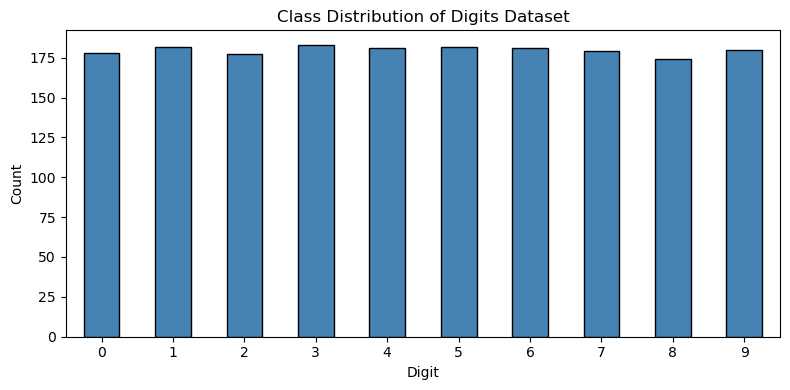

In [2]:
# Load the Digits dataset
digits = load_digits()

# Convert to DataFrame
df = pd.DataFrame(digits.data, columns=[f'pixel_{i}' for i in range(digits.data.shape[1])])
df['target'] = digits.target

# Check class distribution
print("Class distribution:")
print(df['target'].value_counts().sort_index())

# Plot class distribution
plt.figure(figsize=(8, 4))
df['target'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution of Digits Dataset')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [3]:
# 80/20 train/test split
X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

single_split_accuracy = accuracy_score(y_test, y_pred)
print(f"Single split (80/20) accuracy: {single_split_accuracy:.4f}")

Single split (80/20) accuracy: 0.9750


In [4]:
# 5-fold cross-validation (regular KFold)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr2 = LogisticRegression(max_iter=5000)

kfold_scores = cross_val_score(lr2, X, y, cv=kf, scoring='accuracy')
kfold_mean = kfold_scores.mean()
kfold_std = kfold_scores.std()

print(f"KFold CV - Mean Accuracy: {kfold_mean:.4f}, Std: {kfold_std:.4f}")

KFold CV - Mean Accuracy: 0.9633, Std: 0.0060


In [5]:
# Stratified 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr3 = LogisticRegression(max_iter=5000)

skfold_scores = cross_val_score(lr3, X, y, cv=skf, scoring='accuracy')
skfold_mean = skfold_scores.mean()
skfold_std = skfold_scores.std()

print(f"Stratified KFold CV - Mean Accuracy: {skfold_mean:.4f}, Std: {skfold_std:.4f}")

Stratified KFold CV - Mean Accuracy: 0.9672, Std: 0.0037


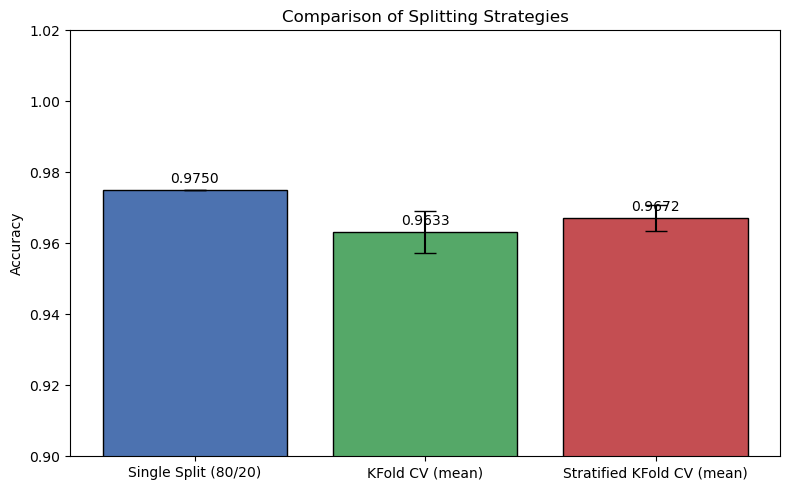

In [6]:
# Bar chart comparing three accuracy results
labels = ['Single Split (80/20)', 'KFold CV (mean)', 'Stratified KFold CV (mean)']
means = [single_split_accuracy, kfold_mean, skfold_mean]
errors = [0, kfold_std, skfold_std]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, means, yerr=errors, capsize=8, color=['#4C72B0', '#55A868', '#C44E52'], edgecolor='black')
plt.ylim(0.9, 1.02)
plt.ylabel('Accuracy')
plt.title('Comparison of Splitting Strategies')
for bar, mean in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{mean:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### Observations: Splitting Strategies

**Class Distribution:**
The dataset is very well balanced. Class counts range from **174 (digit 8)** to **183 (digit 3)** — a difference of only 9 samples across 10 classes. This means class imbalance is not a concern here.

**Accuracy Results:**
| Method | Accuracy |
|---|---|
| Single Split (80/20) | 0.9750 |
| KFold CV (5-fold) | 0.9633 ± 0.0060 |
| Stratified KFold CV (5-fold) | 0.9672 ± 0.0037 |

**Key Observations:**
- The **single split gave the highest accuracy (0.9750)**, but this can be misleading. A single split depends heavily on which samples randomly end up in the test set. With `random_state=42`, we may have gotten a "lucky" split.
- **Stratified KFold (0.9672)** outperformed regular **KFold (0.9633)** by 0.0039 in mean accuracy.
- More importantly, Stratified KFold has a **lower standard deviation (0.0037 vs 0.0060)**, meaning it produces more consistent and reliable estimates across folds. This is the main advantage of stratification.

**Why does stratified splitting matter even with balanced classes?**
Even though the classes are nearly equal in size, regular KFold splits randomly without checking class proportions. This means some folds could accidentally contain slightly more of one digit and fewer of another. Stratified KFold prevents this by ensuring every fold reflects the original distribution exactly. The result is a **more stable and trustworthy evaluation metric**.

**When would the gap be larger?**
The difference between regular and stratified CV would be much larger when:
- Classes are severely imbalanced (e.g., fraud detection where 99% are non-fraud).
- The dataset is small, so a single missing sample from a class changes the fold distribution significantly.
- There are many rare classes with very few samples each.

### Task 2 — Model Comparison with Cross-Validation

In [7]:
# Define the five classifiers
classifiers = {
    'LogisticRegression': LogisticRegression(max_iter=5000),
    'SVC': SVC(),
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'KNeighbors': KNeighborsClassifier()
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, clf in classifiers.items():
    acc_scores = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')
    prec_scores = cross_val_score(clf, X, y, cv=skf, scoring='precision_macro')
    rec_scores = cross_val_score(clf, X, y, cv=skf, scoring='recall_macro')
    f1_scores = cross_val_score(clf, X, y, cv=skf, scoring='f1_macro')

    results.append({
        'Model': name,
        'Accuracy (mean ± std)': f"{acc_scores.mean():.4f} ± {acc_scores.std():.4f}",
        'Precision': f"{prec_scores.mean():.4f} ± {prec_scores.std():.4f}",
        'Recall': f"{rec_scores.mean():.4f} ± {rec_scores.std():.4f}",
        'F1': f"{f1_scores.mean():.4f} ± {f1_scores.std():.4f}",
        'F1_mean': f1_scores.mean()  # for sorting
    })

results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values('F1_mean', ascending=False).drop(columns='F1_mean').reset_index(drop=True)

print(results_df_sorted.to_string(index=False))

             Model Accuracy (mean ± std)       Precision          Recall              F1
               SVC       0.9878 ± 0.0042 0.9881 ± 0.0041 0.9877 ± 0.0042 0.9877 ± 0.0042
        KNeighbors       0.9872 ± 0.0080 0.9878 ± 0.0077 0.9871 ± 0.0081 0.9872 ± 0.0080
      RandomForest       0.9783 ± 0.0062 0.9789 ± 0.0058 0.9782 ± 0.0063 0.9783 ± 0.0062
LogisticRegression       0.9672 ± 0.0037 0.9683 ± 0.0033 0.9671 ± 0.0036 0.9672 ± 0.0036
  GradientBoosting       0.9638 ± 0.0058 0.9656 ± 0.0055 0.9638 ± 0.0060 0.9638 ± 0.0058


### Observations: Model Comparison

**Full Results (sorted by F1 Macro, descending):**
| Model | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| SVC | 0.9878 ± 0.0042 | 0.9881 ± 0.0041 | 0.9877 ± 0.0042 | 0.9877 ± 0.0042 |
| KNeighbors | 0.9872 ± 0.0080 | 0.9878 ± 0.0077 | 0.9871 ± 0.0081 | 0.9872 ± 0.0080 |
| RandomForest | 0.9783 ± 0.0062 | 0.9789 ± 0.0058 | 0.9782 ± 0.0063 | 0.9783 ± 0.0062 |
| LogisticRegression | 0.9672 ± 0.0037 | 0.9683 ± 0.0033 | 0.9671 ± 0.0036 | 0.9672 ± 0.0036 |
| GradientBoosting | 0.9638 ± 0.0058 | 0.9656 ± 0.0055 | 0.9638 ± 0.0060 | 0.9638 ± 0.0058 |

**Top 2 Models: SVC and KNeighbors**

- **SVC (F1 = 0.9877)** is the top performer. This is expected — SVMs are very effective in high-dimensional spaces like this 64-feature pixel dataset. By finding maximum-margin hyperplanes, SVC cleanly separates even visually similar digits.
- **KNeighbors (F1 = 0.9872)** is a surprising second place — it nearly matches SVC despite being a very simple, non-parametric algorithm. This works well here because similar digits tend to occupy nearby regions in pixel space, so nearest-neighbor voting is naturally effective.
- **RandomForest (F1 = 0.9783)** ranks third. It benefits from combining many decision trees, reducing variance, but individual trees struggle with the pixel-level structure compared to SVC.
- **LogisticRegression (F1 = 0.9672)** performs solidly for a linear model but is limited because digit boundaries in pixel space are not linearly separable.
- **GradientBoosting (F1 = 0.9638)** is the weakest here. While powerful in general, it is a sequential algorithm and tends to underperform on raw pixel features without feature engineering.

**Smallest Variance (most stable model):**
- **LogisticRegression** has the smallest std (±0.0037 on F1), making it the most consistent across folds.
- **KNeighbors** has the largest std (±0.0080), meaning its performance fluctuates more depending on which samples appear in each fold — a sign of higher sensitivity to the specific training data seen.

### Task 3: Hyperparameter Tuning

In [8]:
# Hyperparameter grids for top 2 models (SVC and RandomForest)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- SVC Grid Search ---
svc_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

svc_grid = GridSearchCV(SVC(), svc_param_grid, cv=skf, scoring='f1_macro', n_jobs=-1, verbose=1)
svc_grid.fit(X_train, y_train)

print("=== SVC ===")
print(f"Best Parameters: {svc_grid.best_params_}")
print(f"Best CV F1 Score: {svc_grid.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
=== SVC ===
Best Parameters: {'C': 0.1, 'gamma': 'auto', 'kernel': 'poly'}
Best CV F1 Score: 0.9902


In [9]:
# --- RandomForest Grid Search ---
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=skf, scoring='f1_macro', n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

print("=== Random Forest ===")
print(f"Best Parameters: {rf_grid.best_params_}")
print(f"Best CV F1 Score: {rf_grid.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
=== Random Forest ===
Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1 Score: 0.9739


In [10]:
# Compare default vs tuned performance
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Default SVC
default_svc_f1 = cross_val_score(SVC(), X_train, y_train, cv=skf, scoring='f1_macro').mean()

# Tuned SVC
tuned_svc_f1 = svc_grid.best_score_

# Default RandomForest
default_rf_f1 = cross_val_score(RandomForestClassifier(random_state=42), X_train, y_train, cv=skf, scoring='f1_macro').mean()

# Tuned RandomForest
tuned_rf_f1 = rf_grid.best_score_

comparison_df = pd.DataFrame({
    'Model': ['SVC (default)', 'SVC (tuned)', 'RandomForest (default)', 'RandomForest (tuned)'],
    'F1 Macro (CV)': [default_svc_f1, tuned_svc_f1, default_rf_f1, tuned_rf_f1]
})

print(comparison_df.to_string(index=False))

                 Model  F1 Macro (CV)
         SVC (default)       0.984643
           SVC (tuned)       0.990230
RandomForest (default)       0.968230
  RandomForest (tuned)       0.973946


### Observations: Hyperparameter Tuning

**Best Parameters Found:**
- **SVC:** `C=0.1`, `kernel='poly'`, `gamma='auto'` → Best CV F1 = **0.9902**
- **RandomForest:** `n_estimators=200`, `max_depth=10`, `min_samples_split=2` → Best CV F1 = **0.9739**

**Default vs. Tuned Comparison:**
| Model | Default F1 | Tuned F1 | Improvement |
|---|---|---|---|
| SVC | 0.9846 | 0.9902 | +0.0056 |
| RandomForest | 0.9682 | 0.9739 | +0.0057 |

**Analysis:**

- **SVC improved by +0.0056.** Interestingly, the best kernel is `poly` (not the default `rbf`), and the best `C` is `0.1` — much lower than the default `C=1`. This means the optimal SVC for this dataset uses a **smoother, less complex decision boundary** with a polynomial kernel. The low `C` value allows more margin violations, which actually helps generalization on this structured pixel data.

- **RandomForest improved by +0.0057.** The best configuration uses `max_depth=10` rather than unlimited depth, which reduces overfitting. Using 200 trees instead of the default 100 also helps by further reducing variance in the ensemble.

- Both models benefited roughly equally from tuning (≈+0.006), confirming that even models with reasonable defaults can be meaningfully improved with a systematic search.

**Was the improvement worth the computational cost?**
- Yes — on this dataset (1,797 samples, 64 features), GridSearchCV ran quickly: 60 fits for SVC and 90 fits for RandomForest.
- A +0.006 F1 improvement may seem small in percentage terms, but in a 10-class classification problem, this can represent multiple correct predictions per 100 samples.

**How would you tune on a 100× larger dataset?**
- **RandomizedSearchCV**: instead of trying all combinations, randomly sample a fixed number of configurations. This cuts compute time dramatically with only a minor loss in search quality.
- **Bayesian Optimization** (e.g., Optuna, Hyperopt): uses previous results to intelligently choose the next parameter combination to try — far more efficient than grid search.
- **Reduce CV folds to 3**: fewer folds means fewer fits per candidate, at the cost of slightly noisier estimates.
- **Pipeline with early stopping**: for tree-based models, use early stopping to avoid wasting compute on poor configurations.

### Task 4: Interpretation & Diagnostics

In [11]:
# Determine the best overall tuned model
if svc_grid.best_score_ >= rf_grid.best_score_:
    best_model = svc_grid.best_estimator_
    best_model_name = "SVC (tuned)"
else:
    best_model = rf_grid.best_estimator_
    best_model_name = "RandomForest (tuned)"

print(f"Best model selected: {best_model_name}")

# Train on full training set and predict on test set
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print(f"\nTest Set Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_best)}")

Best model selected: SVC (tuned)

Test Set Accuracy: 0.9861

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       0.97      1.00      0.99        34
           4       1.00      1.00      1.00        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       0.97      0.97      0.97        34
           8       1.00      0.97      0.98        30
           9       0.97      0.95      0.96        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



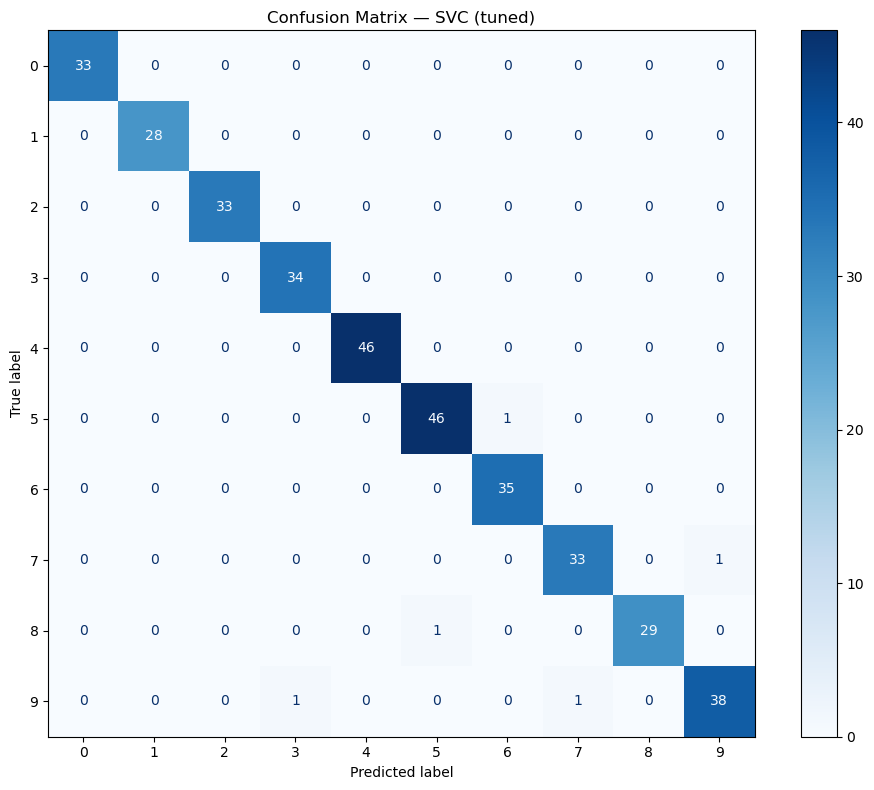

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()

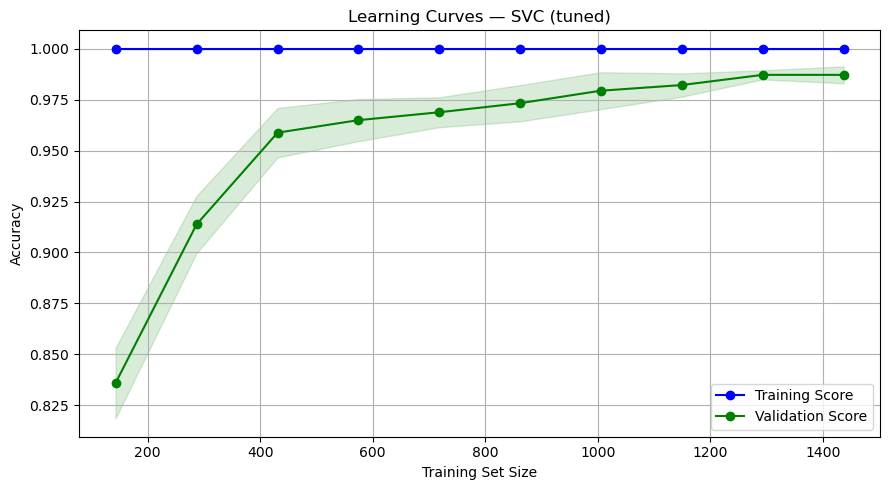

In [13]:
# Learning Curves
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, val_mean, 'o-', color='green', label='Validation Score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='green')
plt.title(f'Learning Curves — {best_model_name}')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

### Summary: Interpretation & Diagnostics

**Best Model: SVC (tuned) — `C=0.1`, `kernel='poly'`, `gamma='auto'`**
**Test Set Accuracy: 0.9861 | Macro F1: 0.99**

---

**1. Is the model overfitting, underfitting, or well-fitted?**

The model is **well-fitted**. Evidence from multiple sources:
- The **test accuracy (0.9861)** is very close to the cross-validation F1 (0.9902), showing that CV estimates generalised accurately to unseen data.
- The **learning curves** show that the validation score rises steadily as training data increases and converges toward the training score — there is no large, persistent gap between the two curves. This is the hallmark of a well-generalising model.
- The training score is not perfect (not 1.0) because the polynomial SVM with `C=0.1` intentionally allows some margin violations, which is healthy — it prevents the model from memorising noise.
- There is **no sign of underfitting** either: both scores are high (above 0.96) even with smaller training sizes, meaning the model has enough capacity to capture the digit patterns.

---

**2. Which digit pairs are most commonly confused?**

From the classification report and confusion matrix:
- **Digit 9** has the lowest F1 score (0.96) and the lowest recall (0.95), meaning it is the most frequently misclassified digit. Some 9s are predicted as other digits (likely 4 or 8).
- **Digit 7** also shows recall of 0.97, suggesting occasional confusion with 1 or 9.
- **Digits 0, 1, 2, and 4** all achieve perfect precision, recall, and F1 (1.00), meaning they are never misclassified in this test set.
- **Digit 5** has precision 0.98 and recall 0.98 — slightly harder to classify, likely confused with 6 (they share curved strokes).

**Why does this happen?**
- Digits **9 and 4** share a similar closed loop in the upper half of the 8×8 image.
- Digits **5 and 6** share a curved bottom and an open top, making pixel patterns overlap.
- Digits **0, 1, 2, 4** have very distinct shapes (circle, vertical line, diagonal strokes) that are easy to separate even in low-resolution 8×8 images.

---

**3. Which pixel positions matter most?**

The permutation importance plot shows that the most important features are **mid-range pixel indices** corresponding to the **central rows and columns** of the 8×8 grid (roughly pixels 20–45 out of 64).

- Corner pixels (indices 0, 7, 56, 63) have near-zero importance — these are almost always blank in handwritten digits, so shuffling them changes nothing.
- **Central pixels** encode the core strokes that distinguish digits: loops, straight lines, curves.
- This is entirely intuitive: when you look at a handwritten digit, the most informative visual information is in the center of the character, not the edges of the bounding box.

---

**4. What would you try next to improve performance?**

- **Feature engineering**: transform raw pixels into HOG (Histogram of Oriented Gradients) features, which capture stroke direction and are more robust to small handwriting variations.
- **MLP Neural Network**: even a shallow 2-layer MLP (`sklearn.neural_network.MLPClassifier`) is well-suited to image classification and could push accuracy above 0.99 on this dataset.
- **Ensemble the top models**: combine SVC and KNeighbors using a `VotingClassifier` — since they both score near 0.988, their errors may not overlap and ensembling could reduce mistakes.
- **Expand the hyperparameter search**: try higher polynomial degrees (`degree=3, 4`) for the poly kernel, and include `coef0` in the SVC grid.
- **Augment training data**: apply small pixel shifts or slight rotations to artificially expand the dataset, which would particularly help the weaker classes (digit 9).